# Exploratory Data Analysis

*Research Question: Can publicly available socioeconomic and geographic data approximate language endangerment status without requiring on-the-ground linguistic assessment?*

This notebook explores key features of the ELCAT and Master data. By exploring the distributions of the features we collected in the 01_data_pipeline step, we can determine which features will be most useful for predicting language endangerment and note any necessary transformations that we will need to make before running the baseline and ensemble models.

### Conclusions and Key Findings

1. *Class Imbalance*

- Threatened and Endangered language categories are the most similar across all features, meaning it will be difficult for the model to find patterns that distinguish them. 
- At Risk and Awakening languages are underrepresented in the dataset with less than 100 samples, creating a class imbalance.

    - Solution: By grouping endangerment categories together, we may be able to increase prediction accuracy. This gives us less granularity on the status, but a better idea of the general trend, which still helps to answer our research question in broad terms.

2. *LEI Index*

- The combination of the domains_of_use, speaker_number, speaker_numer_trends, and transmission features directly produce the ELCAT endangerment category for a given langauge. Using these features will only recreate the ELCAT scoring method by introducing target leakage and inflating correct predictions. 

    - Solution: We will drop these from the model and rely on the socioeconomic features. This will still answer our research question on what features can be used to predict language endangerment without requiring heavy, on-the-ground research. 

3. *Log Transformations*

- GDP and lang_family_count are heavily skewed.

    - Solution: Introduce a log transformation for these features.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [3]:
# Show all columsn in the dataframe
pd.set_option('display.max_columns', None)

In [4]:
elcat = pd.read_csv('../data/elcat_master_df.csv')

In [5]:
elcat.head()

,glottocode,language_name,lang_family,lang_family_count,domains_of_use,speaker_number,speaker_number_trends,transmission,elcat_endangerment,country_count,max_gdp_percapita,avg_gdp_percapita,max_internet,avg_internet,max_urban,avg_urban,max_urban_growth,avg_urban_growth,official,regional,national,minority,widely_spoken,area_Africa,area_Australia,area_Eurasia,area_North America,area_Papunesia,area_South America
0,guri1248,Muno,NaN,0.0,NaN,3.0,NaN,NaN,endangered,1,3006.705645,3006.705645,18.811600,18.811600,15.406182,15.406182,4.067855,4.067855,0,0,0,0,0,0,0,0,0,1,0
1,pawa1255,Pawaia,NaN,0.0,NaN,2.0,NaN,NaN,threatened,1,3006.705645,3006.705645,18.811600,18.811600,15.406182,15.406182,4.067855,4.067855,0,0,0,0,0,0,0,0,0,1,0
2,dama1272,Damal,NaN,0.0,NaN,2.0,2.0,2.0,threatened,1,4925.430488,4925.430488,72.780755,72.780755,58.750964,58.750964,1.897196,1.897196,0,0,0,0,0,0,0,0,0,1,0
3,kusu1250,Kusunda,NaN,0.0,5.0,5.0,5.0,5.0,critically endangered,1,1447.310045,1447.310045,46.321899,46.321899,66.772343,66.772343,0.196823,0.196823,0,0,0,0,0,0,0,1,0,0,0
4,vile1241,Vilela,NaN,0.0,NaN,NaN,NaN,NaN,dormant,1,13969.783660,13969.783660,89.667152,89.667152,92.274232,92.274232,0.432261,0.432261,0,0,0,0,0,0,0,0,0,0,1


In [6]:
print(f"There are {elcat.shape[0]} rows and {elcat.shape[1]} columns in the ELCAT dataset.")

There are 3090 rows and 29 columns in the ELCAT dataset.


In [7]:
elcat.columns

Index(['glottocode', 'language_name', 'lang_family', 'lang_family_count',
       'domains_of_use', 'speaker_number', 'speaker_number_trends',
       'transmission', 'elcat_endangerment', 'country_count',
       'max_gdp_percapita', 'avg_gdp_percapita', 'max_internet',
       'avg_internet', 'max_urban', 'avg_urban', 'max_urban_growth',
       'avg_urban_growth', 'official', 'regional', 'national', 'minority',
       'widely_spoken', 'area_Africa', 'area_Australia', 'area_Eurasia',
       'area_North America', 'area_Papunesia', 'area_South America'],
      dtype='object')

In [8]:
elcat.dtypes

glottocode                object
language_name             object
lang_family               object
lang_family_count        float64
domains_of_use           float64
speaker_number           float64
speaker_number_trends    float64
transmission             float64
elcat_endangerment        object
country_count              int64
max_gdp_percapita        float64
avg_gdp_percapita        float64
max_internet             float64
avg_internet             float64
max_urban                float64
avg_urban                float64
max_urban_growth         float64
avg_urban_growth         float64
official                   int64
regional                   int64
national                   int64
minority                   int64
widely_spoken              int64
area_Africa                int64
area_Australia             int64
area_Eurasia               int64
area_North America         int64
area_Papunesia             int64
area_South America         int64
dtype: object

In [9]:
elcat.describe()

,lang_family_count,domains_of_use,speaker_number,speaker_number_trends,transmission,country_count,max_gdp_percapita,avg_gdp_percapita,max_internet,avg_internet,max_urban,avg_urban,max_urban_growth,avg_urban_growth,official,regional,national,minority,widely_spoken,area_Africa,area_Australia,area_Eurasia,area_North America,area_Papunesia,area_South America
count,3090.000000,538.000000,2825.000000,706.000000,861.000000,3090.000000,3086.000000,3086.000000,3086.000000,3086.000000,3088.000000,3088.000000,3088.000000,3088.000000,3090.000000,3090.000000,3090.000000,3090.000000,3090.000000,3090.000000,3090.000000,3090.000000,3090.000000,3090.000000,3090.000000
mean,447.579612,2.866171,2.504071,3.194051,2.585366,1.307443,18229.085552,17001.798742,65.653845,64.113190,59.489153,57.822936,2.306193,2.188797,0.013269,0.023948,0.005178,0.012298,0.002913,0.187379,0.092557,0.237864,0.101942,0.270550,0.109709
std,520.445116,1.430165,1.257302,1.730172,1.889068,1.284911,26112.944344,24541.148869,28.839823,28.637861,24.855117,24.367093,1.435959,1.403939,0.114441,0.152913,0.071783,0.110229,0.053899,0.390278,0.289857,0.425844,0.302621,0.444316,0.312577
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,413.757895,413.757895,6.671000,6.671000,15.406182,15.406182,-1.825325,-1.825325,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2694.737809,2694.737809,41.211399,41.211399,35.378897,35.378897,1.259365,1.102971,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,227.000000,3.000000,2.000000,4.000000,2.000000,1.000000,4925.430488,4925.430488,72.780755,72.780755,62.975568,61.868934,1.915937,1.897196,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,586.000000,4.000000,3.000000,5.000000,5.000000,1.000000,14889.018555,14185.781225,92.000000,90.867188,80.124780,80.124780,3.362883,3.236117,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1408.000000,5.000000,5.000000,5.000000,5.000000,32.000000,206780.590353,155389.388519,100.000000,99.000000,100.000000,100.000000,7.205344,7.205344,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
elcat.isna().sum()

glottocode                  0
language_name               0
lang_family               113
lang_family_count           0
domains_of_use           2552
speaker_number            265
speaker_number_trends    2384
transmission             2229
elcat_endangerment          0
country_count               0
max_gdp_percapita           4
avg_gdp_percapita           4
max_internet                4
avg_internet                4
max_urban                   2
avg_urban                   2
max_urban_growth            2
avg_urban_growth            2
official                    0
regional                    0
national                    0
minority                    0
widely_spoken               0
area_Africa                 0
area_Australia              0
area_Eurasia                0
area_North America          0
area_Papunesia              0
area_South America          0
dtype: int64

In [11]:
elcat['elcat_endangerment'].value_counts()

threatened               850
endangered               707
vulnerable               498
critically endangered    388
severely endangered      352
dormant                  161
at risk                   81
awakening                 53
Name: elcat_endangerment, dtype: int64

### Distribution of Languages by Endangerment Status

- The majority of languages in the dataset ar either threatened or endangered.
- At risk and awakening languages represent less than ~200 of the 3,000+ languages, creating a heavy class imbalance.

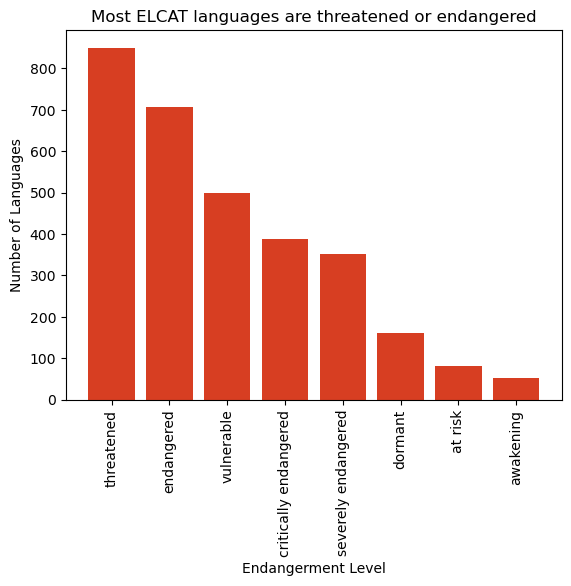

In [12]:
plt.bar(elcat['elcat_endangerment'].value_counts().index, elcat['elcat_endangerment'].value_counts().values, color='#d73e22')
plt.xlabel('Endangerment Level')
plt.xticks(rotation=90)
plt.ylabel('Number of Languages')
plt.title('Most ELCAT languages are threatened or endangered')
plt.show()

### Distribution of Numeric Features by Endangerment Status

- Threatened and endangered languages show very similar patterns across all distributions. The model will likely have a hard time distinguishing between the two categories. 
- Dormant, critically endangered and awakening languages show distinct patterns across internet usage, urban population, language family count, and gdp. We will need to explore further if there is overlap between these features and the areas where the languages are spoken to understand whether or not these features are just a descriptor of the area or the language itself.

/Users/jordan/PATH/Users/jordan/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


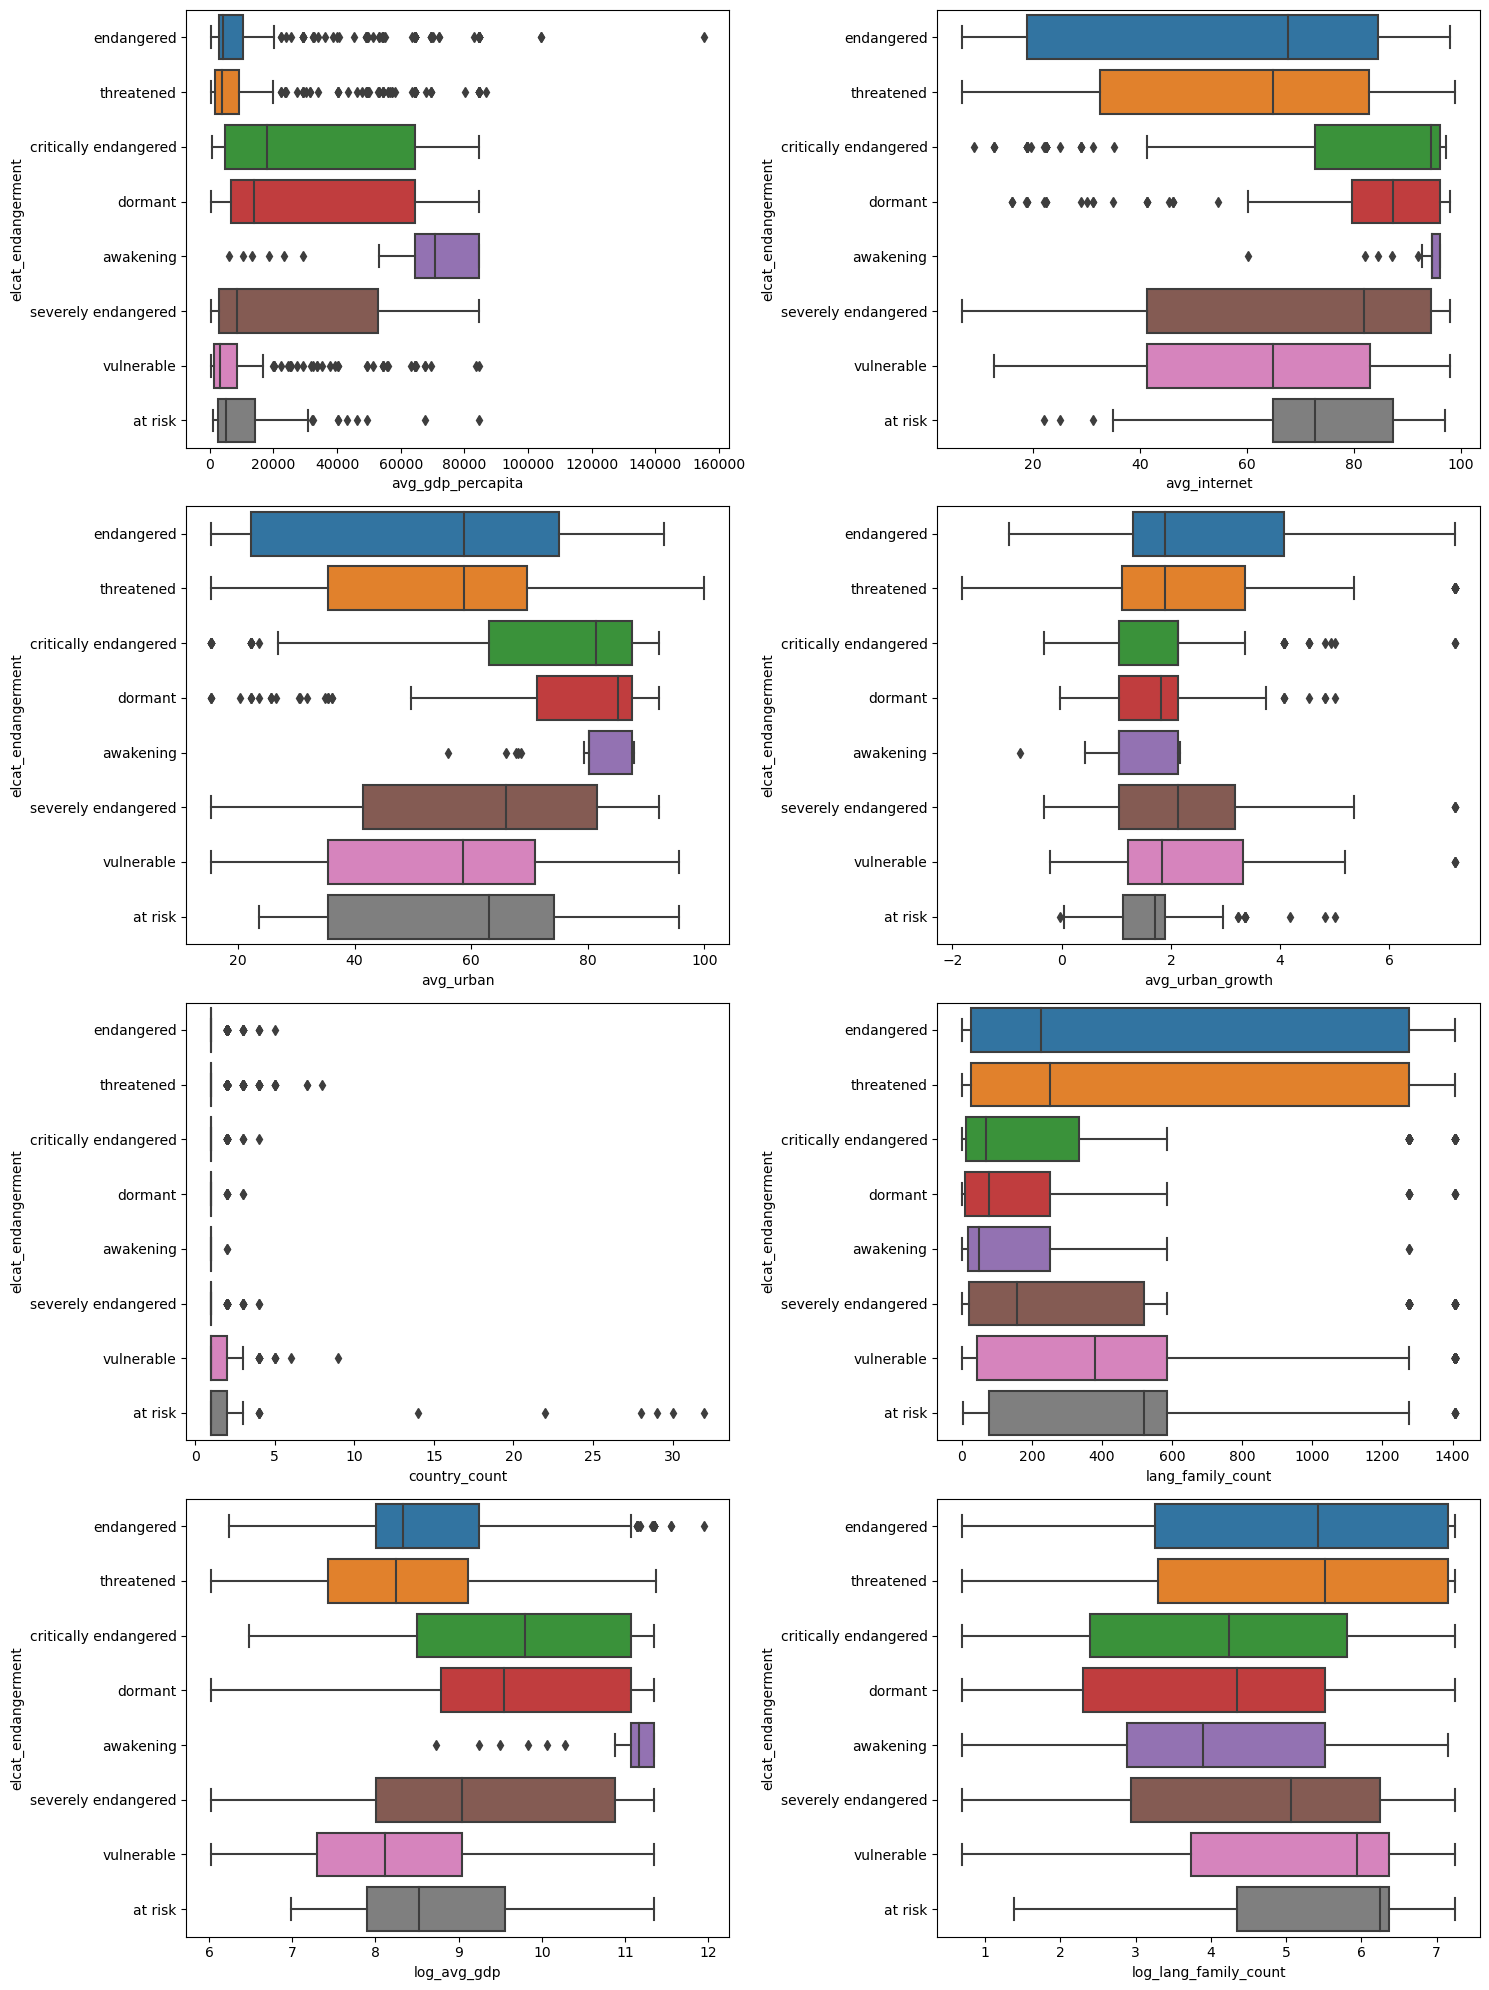

In [13]:
elcat['log_avg_gdp'] = np.log(elcat['avg_gdp_percapita'])
elcat['log_lang_family_count'] = np.log(elcat['lang_family_count'])

elcat_numeric_cols = elcat[['avg_gdp_percapita','avg_internet','avg_urban','avg_urban_growth','country_count','lang_family_count','log_avg_gdp','log_lang_family_count']]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize= (15, 20))
axes = axes.flatten()

for col, ax in zip(elcat_numeric_cols, axes):
    sns.boxplot(data=elcat, y='elcat_endangerment', x=col, ax= ax)
    plt.tight_layout()

### Distribution of Categorical Features by Endangerment Status

*Remember that 0 is essentially the "best" score for all of these, showing languages that are spoken by 100,000+ people, transmitted through generations, used in multiple social domains, and the trends show members of the community all speaking this langage with numbers showing either stable or increasing trends. 5 is the opposite of all this.*

- The LEI index that determines a language's endangerment status is calculated by a combination of these categorical features. They will not be used in our models since that would introduce target leakage, but instead we can use them to compare how a model that only uses publicaly available socioeconomic features compares to a model where the data must be hand-collected by experts, usually in the areas where the language is spoken. This can give us an idea of how well we can predict language endangerment without requiring extensive hands-on research, leading to quicker policy decisions and action.  

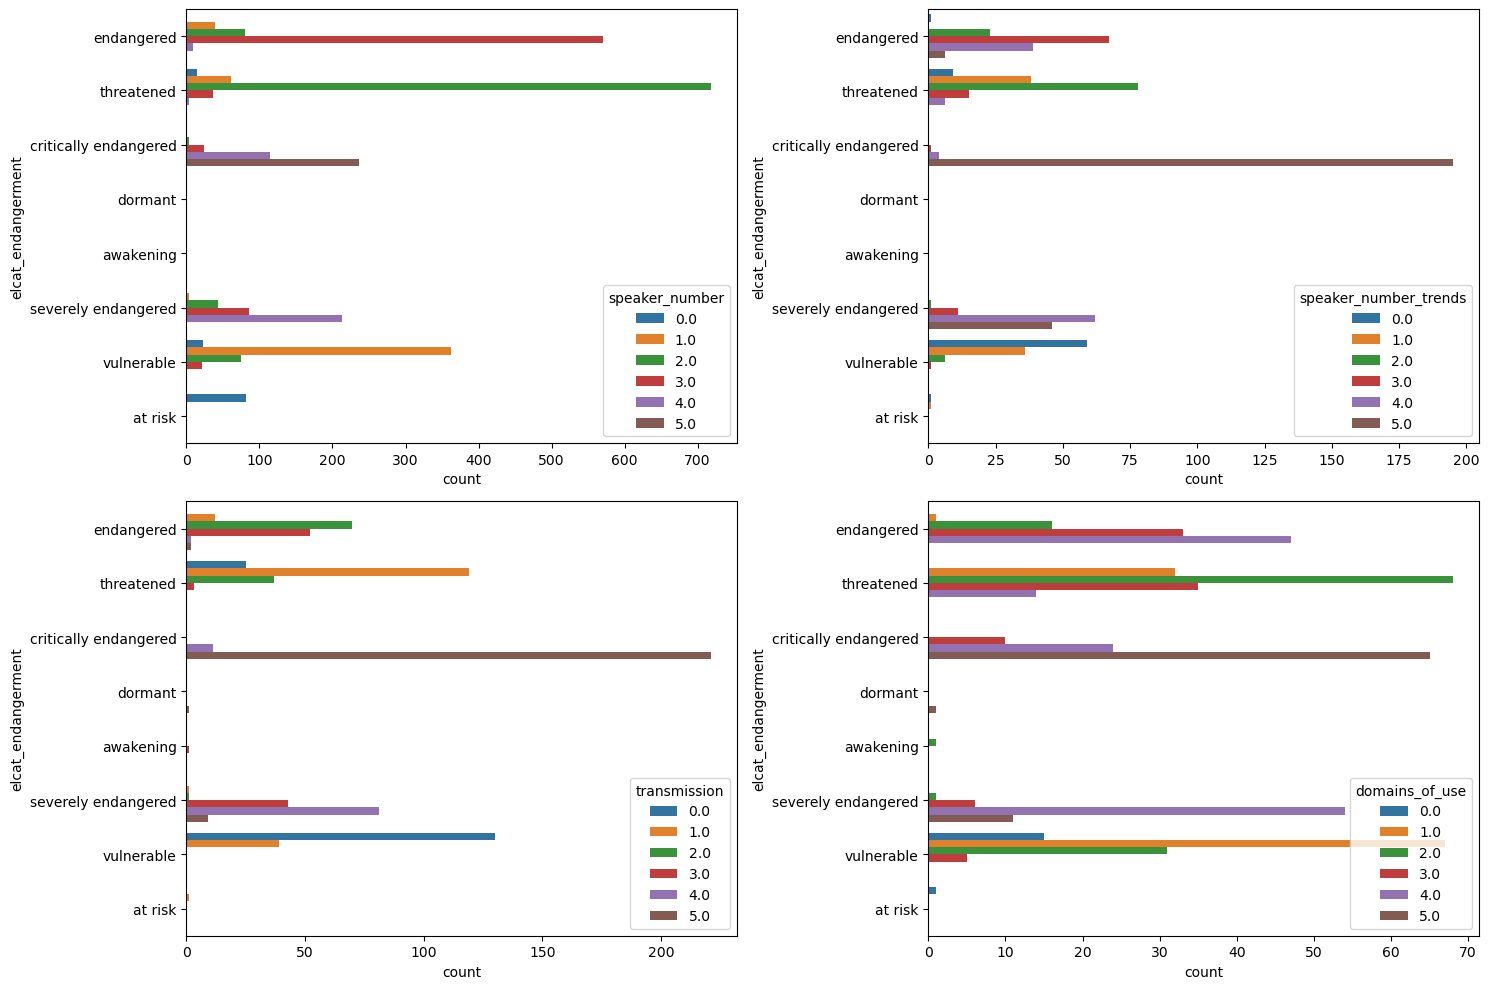

In [14]:
elcat_categorical_cols = ['speaker_number','speaker_number_trends','transmission','domains_of_use']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize= (15,10))
axes = axes.flatten()

for col, ax in zip(elcat_categorical_cols, axes):
    sns.countplot(data=elcat, y= 'elcat_endangerment', hue=col, ax=ax)

plt.tight_layout()

### Geographic Distribution by Endangerment Level

- The stacked bar chart below reveals that the category of endangerment is not singularly concentrated in any one macroarea. However, there are some noticable patterns, such as Australia having a higher concentration of Awakening, Critically Endnagered and Dormant languages, that may be useful in predicting the langauge endangerment level based on the macroarea the language is spoken in. 

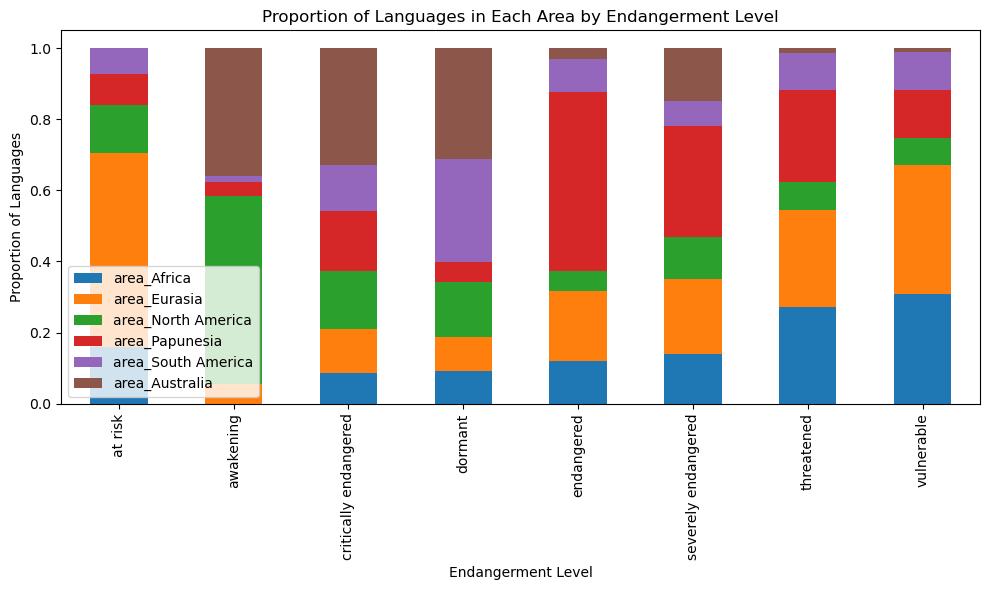

In [15]:
area_cols = ['area_Africa','area_Eurasia','area_North America','area_Papunesia','area_South America', 'area_Australia']

area_by_status = elcat.groupby('elcat_endangerment')[area_cols].mean()
area_by_status.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Endangerment Level')
plt.ylabel('Proportion of Languages')
plt.title('Proportion of Languages in Each Area by Endangerment Level')
plt.tight_layout()